In [ ]:
# 強度１～３のOGVC特徴量（くしなだ使用）で感情強度推定器を学習させる
# /home/mitani/kusinada_ogvc_emo_int-s3prl-jtes.ipynbを流用（入力データを変えただけ）

In [43]:
# s3prlの「くしなだ」で抽出した特徴量で感情＆強度推定
# ======================================================
# OGVC Kushinada 特徴量版：Emotion（分類）/ Intensity（回帰）
# ======================================================

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# ================================
# 設定
# ================================
RESULT_DIR = "results_kushinada_emo_int"
os.makedirs(RESULT_DIR, exist_ok=True)

EMOTION_LABELS = {
    "JOY": 0, "ACC": 1, "FEA": 2, "SUR": 3,
    "SAD": 4, "DIS": 5, "ANG": 6, "ANT": 7,
    "NEU": 8, "OTH": 9
}

# =========================================================
# 混同行列
# =========================================================
def plot_conf_matrix(true, pred, labels, title, save_path, exclude_labels=None):
    cm = confusion_matrix(true, pred, labels=range(len(labels)))                    # labels=range(len(labels))

    if exclude_labels is not None:
        exclude_idx = [labels.index(l) for l in exclude_labels]
        cm = np.delete(cm, exclude_idx, axis=0)
        cm = np.delete(cm, exclude_idx, axis=1)
        labels = [l for l in labels if l not in exclude_labels]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

def plot_intensity_conf_matrix(true, pred, title, save_path):       # 強度用の混同行列

    labels = [1,2,3]

    cm = confusion_matrix(
        true,
        pred,
        labels=labels
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues"
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

# =========================================================
# Step1: データ読み込み
# =========================================================
def step1_load_data(csv_path):
    df = pd.read_csv(csv_path)
    print("=== Step1: データ読み込み完了 ===")
    print(df.head())
    return df

# =========================================================
# Step2: 学習
# =========================================================
def step2_train_model(df):
    SPLIT_DIR = "kushinada_split_data"
    TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
    TEST_DIR = os.path.join(SPLIT_DIR, "test")
    os.makedirs(TRAIN_DIR, exist_ok=True)
    os.makedirs(TEST_DIR, exist_ok=True)

    # ---------- 特徴量 ----------
    feature_df = df.drop(columns=["emotion", "intensity"])
    numeric_cols = feature_df.select_dtypes(include=[np.number]).columns
    X = feature_df[numeric_cols]

    # ---------- ラベル ----------
    y_emo = df["emotion"].map(EMOTION_LABELS)
    y_int = df["intensity"]

    # ---------- 分割 ----------
    X_train, X_test, emo_train, emo_test, int_train, int_test = train_test_split(
        X, y_emo, y_int,
        test_size=0.2,
        random_state=42,
        stratify=y_emo
    )

    # ---------- 保存 ----------
    df.loc[X_train.index].to_csv(os.path.join(TRAIN_DIR, "train_data_out0.csv"), index=False)
    df.loc[X_test.index].to_csv(os.path.join(TEST_DIR, "test_data_out0.csv"), index=False)

    # ============================
    # モデル
    # ============================

    # 感情（分類）
    emo_model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000))
    ])
    emo_model.fit(X_train, emo_train)

    # 強度（回帰）
    int_model = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0))
    ])
    int_model.fit(X_train, int_train)

    print("=== Step2: モデル学習完了 ===")

    # ---------- 保存 ----------
    joblib.dump(emo_model, os.path.join(RESULT_DIR, "emo_model_out0.pkl"))
    joblib.dump(int_model, os.path.join(RESULT_DIR, "int_model_out0.pkl"))

    return {
        "X_test": X_test,
        "filename_test": df.loc[X_test.index, "filename"],
        "emo_test": emo_test,
        "int_test": int_test,
        "emo_model": emo_model,
        "int_model": int_model
    }

# =========================================================
# Step3: 評価
# =========================================================
def step3_evaluate(data):
    X_test = data["X_test"]
    filename_test = data["filename_test"]
    emo_test = data["emo_test"]
    int_test = data["int_test"]
    emo_model = data["emo_model"]
    int_model = data["int_model"]

    # ---------- 予測 ----------
    emo_pred = emo_model.predict(X_test)
    int_pred = int_model.predict(X_test)

    # ============================
    # 感情（分類）
    # ============================
    print("\n=== Emotion Classification ===")
    print(classification_report(emo_test, emo_pred))

    emo_cm_path = os.path.join(RESULT_DIR, "confusion_emotion_out0.png")
    plot_conf_matrix(
        emo_test, emo_pred,
        list(EMOTION_LABELS.keys()),
        "Emotion Confusion Matrix",
        emo_cm_path,
        exclude_labels=["NEU", "OTH"]
    )

    # ============================
    # 強度（回帰）
    # ============================
    print("\n=== Intensity Regression ===")
    mse = mean_squared_error(int_test, int_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(int_test, int_pred)
    r2 = r2_score(int_test, int_pred)

    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R2   : {r2:.4f}")

    # ---------- 可視化（散布図） ----------
    plt.figure()
    plt.scatter(int_test, int_pred, alpha=0.5)
    plt.xlabel("True Intensity")
    plt.ylabel("Predicted Intensity")
    plt.title("Intensity Regression Scatter")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, "intensity_scatter_out0.png"))
    plt.close()

    # ---------- 丸め ----------
    # 保存先
    int_cm_path = os.path.join(
    RESULT_DIR,
    "confusion_intensity_rounded_out0.png"
    )
    
    int_pred_round = np.clip(
        np.round(int_pred),
        1,
        3
    ).astype(int)

    plot_intensity_conf_matrix(
        int_test,
        int_pred_round,
        "Intensity (Rounded) Confusion Matrix",
        int_cm_path
    )

    # ============================
    # CSV保存
    # ============================
    pred_df = pd.DataFrame({
        "filename": filename_test,
        "emotion_true": emo_test,
        "emotion_pred": emo_pred,
        "intensity_true": int_test,
        "intensity_pred": int_pred
    })

    pred_path = os.path.join(RESULT_DIR, "pred_results_out0.csv")
    pred_df.to_csv(pred_path, index=False)

    print("\n結果保存:")
    print("Emotion CM:", emo_cm_path)
    print("Intensity Scatter:", "intensity_scatter_out0.png")
    print("Prediction CSV:", pred_path)

# =========================================================
# メイン
# =========================================================
if __name__ == "__main__":
    df = step1_load_data(
        "/home/mitani/ogvc_kushinada_features-s3prl-jtes_without0.csv"
    )
    data = step2_train_model(df)
    step3_evaluate(data)

    print("\n=== 完了（分類＋回帰） ===")

=== Step1: データ読み込み完了 ===
          filename emotion  intensity     ssl_0     ssl_1     ssl_2     ssl_3  \
0  FOY0806ANG2.wav     ANG          2  2.575597 -1.512569  0.211377 -0.196105   
1  FOY0101ANT2.wav     ANT          2  4.339159 -1.426112  0.345574  0.084326   
2  FOY0101ANT3.wav     ANT          3  4.919140 -1.841724 -0.154893  0.001038   
3  FOY0104FEA3.wav     FEA          3  3.512141 -1.741795 -0.022846 -0.373154   
4  FOY0106FEA2.wav     FEA          2  4.760804 -0.772446  0.318058 -0.424879   

      ssl_4     ssl_5     ssl_6  ...   ssl_758   ssl_759   ssl_760   ssl_761  \
0  1.268040  2.750185  0.407414  ...  2.443617  2.699654  2.701334  1.711129   
1  0.511528  0.115045  3.028395  ...  0.138740  1.146498  3.801486  2.826327   
2  0.329440 -0.273892  2.128931  ...  0.392319  1.096165  3.583391  2.765215   
3  1.007201  1.278266  1.817713  ...  3.346642  3.443441  2.978347  1.153409   
4 -0.904945  2.017470  2.121992  ...  2.397361  2.774574  2.481201 -0.103077   

    ssl

In [2]:
# ======================================================
# OGVC Kushinada 特徴量版：
# Emotion（分類）/ Intensity（回帰：1〜3対応）
# ======================================================

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# ================================
# 設定
# ================================
RESULT_DIR = "results_kushinada_emo_int"
os.makedirs(RESULT_DIR, exist_ok=True)

EMOTION_LABELS = {
    "JOY": 0, "ACC": 1, "FEA": 2, "SUR": 3,
    "SAD": 4, "DIS": 5, "ANG": 6, "ANT": 7,
    "NEU": 8, "OTH": 9
}

INTENSITY_MAX = 3  # ← ここ重要（0〜3）, 3

# =========================================================
# 混同行列
# =========================================================
def plot_conf_matrix(true, pred, labels, title, save_path, exclude_labels=None, vmax=None):
    cm = confusion_matrix(true, pred, labels=range(len(labels)))

    if exclude_labels is not None:
        exclude_idx = [labels.index(l) for l in exclude_labels]
        cm = np.delete(cm, exclude_idx, axis=0)
        cm = np.delete(cm, exclude_idx, axis=1)
        labels = [l for l in labels if l not in exclude_labels]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=labels, yticklabels=labels, cmap="Blues", vmin=0, vmax=60, annot_kws={"size": 16})      # vmax
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

# =========================================================
# Step1: データ読み込み
# =========================================================
def step1_load_data(csv_path):
    df = pd.read_csv(csv_path)

    # 念のため範囲制限（0〜3）
    df["intensity"] = df["intensity"].clip(0, INTENSITY_MAX)

    print("=== Step1: データ読み込み完了 ===")
    print(df.head())
    return df

# =========================================================
# Step2: 学習
# =========================================================
def step2_train_model(df):
    SPLIT_DIR = "kushinada_split_data"
    TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
    TEST_DIR = os.path.join(SPLIT_DIR, "test")
    os.makedirs(TRAIN_DIR, exist_ok=True)
    os.makedirs(TEST_DIR, exist_ok=True)

    # ---------- 特徴量 ----------
    feature_df = df.drop(columns=["emotion", "intensity"])
    numeric_cols = feature_df.select_dtypes(include=[np.number]).columns
    X = feature_df[numeric_cols]

    # ---------- ラベル ----------
    y_emo = df["emotion"].map(EMOTION_LABELS)

    # ★ 強度を正規化（0〜1）
    y_int = df["intensity"] / INTENSITY_MAX

    # ---------- 分割 ----------
    X_train, X_test, emo_train, emo_test, int_train, int_test = train_test_split(
        X, y_emo, y_int,
        test_size=0.2,
        random_state=42,
        stratify=y_emo
    )

    # ---------- 保存 ----------
    df.loc[X_train.index].to_csv(os.path.join(TRAIN_DIR, "train_data.csv"), index=False)
    df.loc[X_test.index].to_csv(os.path.join(TEST_DIR, "test_data.csv"), index=False)

    # ============================
    # モデル
    # ============================

    # 感情（分類）
    emo_model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000))
    ])
    emo_model.fit(X_train, emo_train)

    # 強度（回帰）
    int_model = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0))
    ])
    int_model.fit(X_train, int_train)

    print("=== Step2: モデル学習完了 ===")

    # ---------- 保存 ----------
    joblib.dump(emo_model, os.path.join(RESULT_DIR, "kusinada_csj_emo_model-s3prl-jtes_out0.pkl"))
    joblib.dump(int_model, os.path.join(RESULT_DIR, "kusinada_csj_int_model-s3prl-jtes_out0.pkl"))

    # ============================
    # 特徴量の列順を保存（超重要）
    # ============================
    joblib.dump(
        list(numeric_cols),
        os.path.join(RESULT_DIR, "kusinada_feature_columns_out0.pkl")
    )

    return {
        "X_test": X_test,
        "filename_test": df.loc[X_test.index, "filename"],
        "emo_test": emo_test,
        "int_test": int_test,
        "emo_model": emo_model,
        "int_model": int_model
    }

# =========================================================
# Step3: 評価
# =========================================================
def step3_evaluate(data):
    X_test = data["X_test"]
    filename_test = data["filename_test"]
    emo_test = data["emo_test"]
    int_test = data["int_test"]
    emo_model = data["emo_model"]
    int_model = data["int_model"]

    # ---------- 予測 ----------
    emo_pred = emo_model.predict(X_test)

    # ★ 0〜1 → 0〜3に戻す
    int_pred = int_model.predict(X_test) * INTENSITY_MAX
    int_true = int_test * INTENSITY_MAX

    # ============================
    # Emotion（分類）
    # ============================
    print("\n=== Emotion Classification ===")
    print(classification_report(emo_test, emo_pred))

    plot_conf_matrix(
        emo_test, emo_pred,
        list(EMOTION_LABELS.keys()),
        "Emotion Confusion Matrix",
        os.path.join(RESULT_DIR, "confusion_emotion_out0.png"),
        exclude_labels=["NEU", "OTH"]
    )

    # ============================
    # Intensity（回帰）
    # ============================
    print("\n=== Intensity Regression ===")

    mse = mean_squared_error(int_true, int_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(int_true, int_pred)
    r2 = r2_score(int_true, int_pred)

    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R2   : {r2:.4f}")

    # ---------- 散布図 ----------
    plt.figure()
    plt.scatter(int_true, int_pred, alpha=0.5)
    plt.xlabel("True Intensity")
    plt.ylabel("Predicted Intensity")
    plt.title("Intensity Regression (0-3)")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, "intensity_scatter_out0.png"))
    plt.close()

    # ============================
    # 丸めて分類評価（比較用）
    # ============================
    int_pred_round = np.clip(np.round(int_pred), 0, INTENSITY_MAX).astype(int)

    print("\n=== Intensity (Rounded Classification) ===")
    print(classification_report(int_true.astype(int), int_pred_round))

    plot_conf_matrix(
        int_true.astype(int),
        int_pred_round,
        ["0", "1", "2", "3"],       # "0", "1", "2", "3"
        "Intensity Confusion Matrix (Rounded)",
        os.path.join(RESULT_DIR, "confusion_intensity_out0.png"),
        vmax=120
    )

    # ============================
    # CSV保存
    # ============================
    pred_df = pd.DataFrame({
        "filename": filename_test,
        "emotion_true": emo_test,
        "emotion_pred": emo_pred,
        "intensity_true": int_true,
        "intensity_pred": int_pred,
        "intensity_pred_round": int_pred_round
    })

    pred_df.to_csv(os.path.join(RESULT_DIR, "pred_results_out0.csv"), index=False)

    print("\n=== 結果保存完了 ===")

# =========================================================
# メイン
# =========================================================
if __name__ == "__main__":
    df = step1_load_data(
        "ogvc_kushinada_features-s3prl-jtes_without0.csv"
    )
    data = step2_train_model(df)
    step3_evaluate(data)

    print("\n=== 完了（4段階強度＋回帰） ===")

=== Step1: データ読み込み完了 ===
          filename emotion  intensity     ssl_0     ssl_1     ssl_2     ssl_3  \
0  FOY0806ANG2.wav     ANG          2  2.575597 -1.512569  0.211377 -0.196105   
1  FOY0101ANT2.wav     ANT          2  4.339159 -1.426112  0.345574  0.084326   
2  FOY0101ANT3.wav     ANT          3  4.919140 -1.841724 -0.154893  0.001038   
3  FOY0104FEA3.wav     FEA          3  3.512141 -1.741795 -0.022846 -0.373154   
4  FOY0106FEA2.wav     FEA          2  4.760804 -0.772446  0.318058 -0.424879   

      ssl_4     ssl_5     ssl_6  ...   ssl_758   ssl_759   ssl_760   ssl_761  \
0  1.268040  2.750185  0.407414  ...  2.443617  2.699654  2.701334  1.711129   
1  0.511528  0.115045  3.028395  ...  0.138740  1.146498  3.801486  2.826327   
2  0.329440 -0.273892  2.128931  ...  0.392319  1.096165  3.583391  2.765215   
3  1.007201  1.278266  1.817713  ...  3.346642  3.443441  2.978347  1.153409   
4 -0.904945  2.017470  2.121992  ...  2.397361  2.774574  2.481201 -0.103077   

    ssl

/home/mitani/.conda/envs/ser/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mitani/.conda/envs/ser/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mitani/.conda/envs/ser/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
# 感情を数値からラベルに変換
import pandas as pd

# ================================
# ラベル定義（元と同じ）
# ================================
EMOTION_LABELS = {
    "JOY": 0, "ACC": 1, "FEA": 2, "SUR": 3,
    "SAD": 4, "DIS": 5, "ANG": 6, "ANT": 7,
    "NEU": 8, "OTH": 9
}

# ================================
# 逆変換辞書（数値 → ラベル）
# ================================
ID2EMO = {v: k for k, v in EMOTION_LABELS.items()}

# ================================
# CSV読み込み
# ================================
csv_path = "results_kushinada_emo_int/pred_results_out0.csv"
df = pd.read_csv(csv_path)

# ================================
# 数値 → ラベル変換
# ================================
df["emotion_true_label"] = df["emotion_true"].map(ID2EMO)
df["emotion_pred_label"] = df["emotion_pred"].map(ID2EMO)

# ================================
# 保存
# ================================
output_path = "results_kushinada_emo_int/pred_results_with_label-kusinada_out0.csv"
df.to_csv(output_path, index=False)

print("変換完了 →", output_path)

変換完了 → results_kushinada_emo_int/pred_results_with_label-kusinada_out0.csv


In [31]:
# 上記の結果を読み込んでMAEやRMSEで評価
import os
import pandas as pd
import numpy as np

# ================================
# 設定
# ================================
RESULT_DIR = "results_kushinada_emo_int"

csv_path = os.path.join(
    RESULT_DIR,
    "pred_results_with_label-kusinada_out0.csv"
)

out_path = os.path.join(
    RESULT_DIR,
    "eval_emotion_wise_intensity_mae_rmse-kusinada_out0.csv"
)

# ================================
# CSV読み込み
# ================================
df = pd.read_csv(csv_path)

# ================================
# 誤差計算
# ================================
signed_error = df["intensity_pred"] - df["intensity_true"]
df["sq_error"] = signed_error ** 2

# ⭐ 追加（ここが重要）
df["intensity_abs_error"] = abs(signed_error)

# ================================
# 1️⃣ モデル全体 MAE / RMSE
# ================================
overall_mae = df["intensity_abs_error"].mean()
overall_rmse = np.sqrt(df["sq_error"].mean())

print("=== Overall Intensity Performance (Kushinada) ===")
print(f"MAE  : {overall_mae:.4f}")
print(f"RMSE : {overall_rmse:.4f}")

# ================================
# 2️⃣ 感情カテゴリ別 MAE / RMSE
# ================================
emotion_metrics = (
    df.groupby("emotion_true_label")
      .agg(
          MAE=("intensity_abs_error", "mean"),
          RMSE=("sq_error", lambda x: np.sqrt(x.mean())),
          Count=("filename", "count")
      )
      .reset_index()
)

print("\n=== Emotion-wise Intensity Performance (Kushinada) ===")
print(emotion_metrics)

# ================================
# 保存
# ================================
emotion_metrics.to_csv(out_path, index=False)
print(f"\nSaved to: {out_path}")

=== Overall Intensity Performance (Kushinada) ===
MAE  : 0.4531
RMSE : 0.5759

=== Emotion-wise Intensity Performance (Kushinada) ===
  emotion_true_label       MAE      RMSE  Count
0                ACC  0.543802  0.685141     48
1                ANG  0.382789  0.471649     48
2                ANT  0.345634  0.412293     48
3                DIS  0.492088  0.616985     48
4                FEA  0.478581  0.609195     48
5                JOY  0.485688  0.613727     50
6                SAD  0.397818  0.496964     51
7                SUR  0.492412  0.635981     58

Saved to: results_kushinada_emo_int/eval_emotion_wise_intensity_mae_rmse-kusinada_out0.csv


In [32]:
# 「くしなだ」分類精度（Accuracy）の確認
import pandas as pd

df = pd.read_csv("results_kushinada_emo_int/pred_results_with_label-kusinada_out0.csv")

acc = (df["emotion_true_label"] == df["emotion_pred_label"]).mean()

print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9774


In [33]:
# 「いざなみ」分類精度（Accuracy）の確認
import pandas as pd

df = pd.read_csv("results_ogvc_emo_int-izanami/pred_results_with_emotion_label-s3prl-jtes_out0.csv")

acc = (df["emotion_true_label"] == df["emotion_pred_label"]).mean()

print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9373


In [34]:
# 強度の分布確認（異常検知）
import pandas as pd

df = pd.read_csv("results_kushinada_emo_int/pred_results_with_label-kusinada_out0.csv")

print("=== TRUE intensity ===")
print(df["intensity_true"].describe())

print("\n=== PRED intensity ===")
print(df["intensity_pred"].describe())

=== TRUE intensity ===
count    399.000000
mean       1.954887
std        0.822406
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        3.000000
Name: intensity_true, dtype: float64

=== PRED intensity ===
count    399.000000
mean       1.992918
std        0.815061
min       -0.179187
25%        1.396803
50%        2.054987
75%        2.590723
max        3.655757
Name: intensity_pred, dtype: float64


In [35]:
# 「くしなだ」相関係数
import pandas as pd

df = pd.read_csv("results_kushinada_emo_int/pred_results_with_label-kusinada_out0.csv")

corr = df[["intensity_true", "intensity_pred"]].corr()

print("=== Correlation ===")
print(corr)

=== Correlation ===
                intensity_true  intensity_pred
intensity_true        1.000000        0.753088
intensity_pred        0.753088        1.000000


In [36]:
# 「いざなみ」相関係数
import pandas as pd

df = pd.read_csv("results_ogvc_emo_int-izanami/pred_results_with_emotion_label-s3prl-jtes_out0.csv")

corr = df[["intensity_true", "intensity_pred"]].corr()

print("=== Correlation ===")
print(corr)

=== Correlation ===
                intensity_true  intensity_pred
intensity_true        1.000000        0.742307
intensity_pred        0.742307        1.000000


In [37]:
# いざなみ vs くしなだ 比較
import pandas as pd

df_k = pd.read_csv("results_kushinada_emo_int/pred_results_with_label-kusinada_out0.csv")
df_i = pd.read_csv("results_ogvc_emo_int-izanami/pred_results_with_emotion_label-s3prl-jtes_out0.csv")

# 誤差作成
df_k["abs_error"] = abs(df_k["intensity_pred"] - df_k["intensity_true"])
df_i["abs_error"] = abs(df_i["intensity_pred"] - df_i["intensity_true"])

print("=== MAE ===")
print("Kushinada:", df_k["abs_error"].mean())
print("Izanami  :", df_i["abs_error"].mean())

print("\n=== Accuracy ===")
acc_k = (df_k["emotion_true_label"] == df_k["emotion_pred_label"]).mean()
acc_i = (df_i["emotion_true_label"] == df_i["emotion_pred_label"]).mean()

print("Kushinada:", acc_k)
print("Izanami  :", acc_i)

=== MAE ===
Kushinada: 0.4531126271761147
Izanami  : 0.46402882440839605

=== Accuracy ===
Kushinada: 0.9774436090225563
Izanami  : 0.9373433583959899


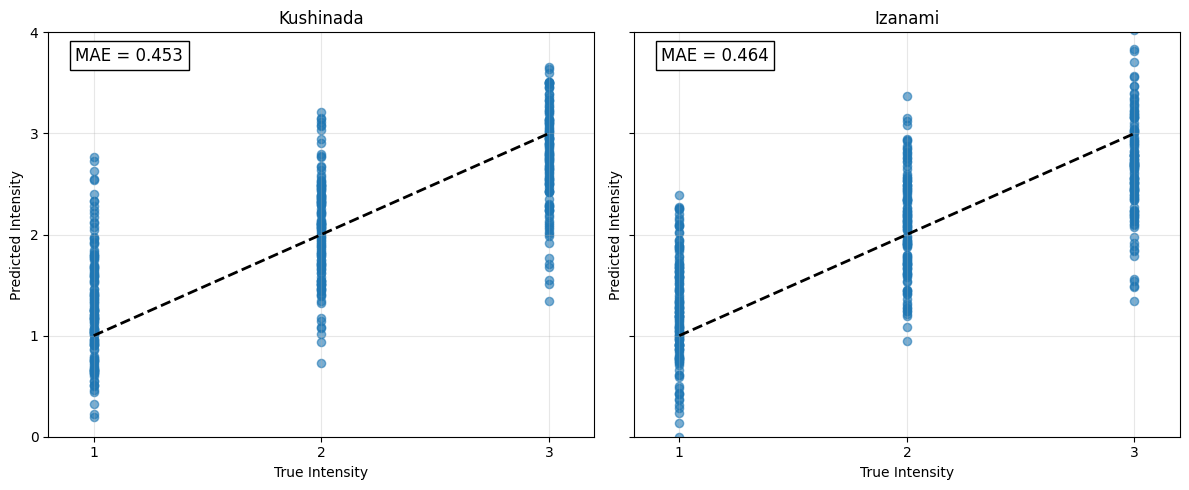

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# データ読み込み
df_k = pd.read_csv("/home/mitani/results_kushinada_emo_int/pred_results_with_label-kusinada_out0.csv")
df_i = pd.read_csv("/home/mitani/results_ogvc_emo_int-izanami/pred_results_with_emotion_label-s3prl-jtes_out0.csv")

# ==========================
# MAE計算
# ==========================
df_k["abs_error"] = abs(df_k["intensity_pred"] - df_k["intensity_true"])
df_i["abs_error"] = abs(df_i["intensity_pred"] - df_i["intensity_true"])

mae_k = df_k["abs_error"].mean()
mae_i = df_i["abs_error"].mean()

# ==========================
# 描画
# ==========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

datasets = [
    (df_k, "Kushinada", mae_k),
    (df_i, "Izanami", mae_i)
]

for ax, (df, title, mae) in zip(axes, datasets):

    # 散布図
    ax.scatter(
        df["intensity_true"],
        df["intensity_pred"],
        s=35,
        alpha=0.6
    )

    # 横軸（正解値）
    ax.set_xlim(0.8, 3.2)
    ax.set_xticks([1, 2, 3])

    # 縦軸（予測値）
    ax.set_ylim(0, 4)
    ax.set_yticks([0, 1, 2, 3, 4])

    # 理想線 y=x
    ax.plot([1, 3], [1, 3], "k--", linewidth=2)

    # ラベル
    ax.set_xlabel("True Intensity")
    ax.set_ylabel("Predicted Intensity")

    # タイトル
    ax.set_title(title)

    # MAE表示
    ax.text(
        0.05,
        0.93,
        f"MAE = {mae:.3f}",
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black")
    )

    # グリッド
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()